In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
# Graphs thode bade aur readable banane ke liye
plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/laptop_price.csv")

In [5]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [6]:
df["Company"].value_counts()

Company
Dell         291
Lenovo       289
HP           268
Asus         152
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

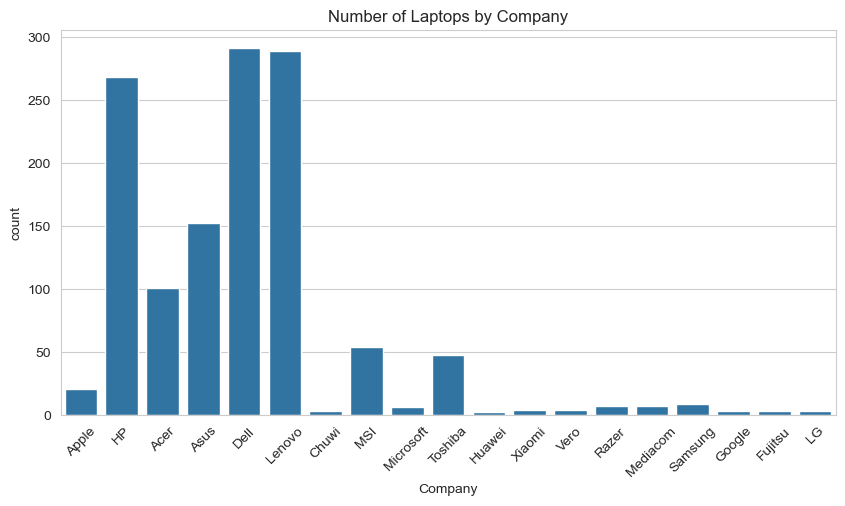

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Company")

plt.title("Number of Laptops by Company")
plt.xticks(rotation=45)

plt.show()

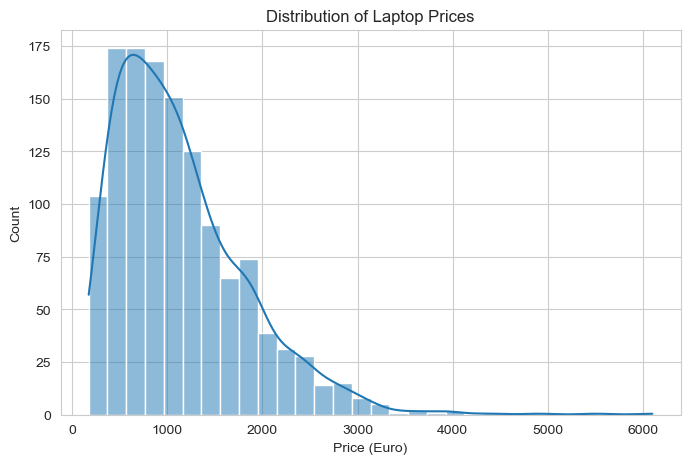

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price (Euro)"], bins=30, kde=True)

plt.title("Distribution of Laptop Prices")

plt.show()

In [9]:
df["Price (Euro)"].describe()

count    1275.000000
mean     1134.969059
std       700.752504
min       174.000000
25%       609.000000
50%       989.000000
75%      1496.500000
max      6099.000000
Name: Price (Euro), dtype: float64

## Price Distribution Observations

- Dataset contains 1275 laptop records.
- Average laptop price is approximately 1135 Euros.
- Median price is 989 Euros.
- Mean is greater than median, indicating a right-skewed distribution.
- Most laptop prices lie between 609 and 1496 Euros.
- A few premium laptops priced above 4000 Euros act as outliers.

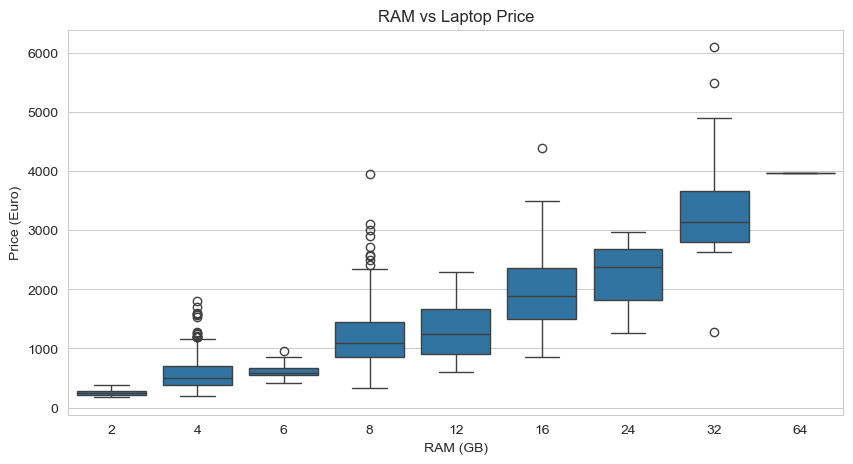

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(x="RAM (GB)", y="Price (Euro)", data=df)

plt.title("RAM vs Laptop Price")

plt.show()

## Observation

- Dataset is right-skewed.
- Most laptops cost between 500 and 1500 Euros.
- High-end laptops create outliers.

## RAM vs Price Observations

- Laptop price generally increases as RAM increases.
- 8 GB and 16 GB are the most common RAM configurations.
- Higher RAM laptops are generally more expensive.
- Some expensive 4 GB and 8 GB laptops exist due to premium features.
- RAM has a strong positive relationship with laptop price.

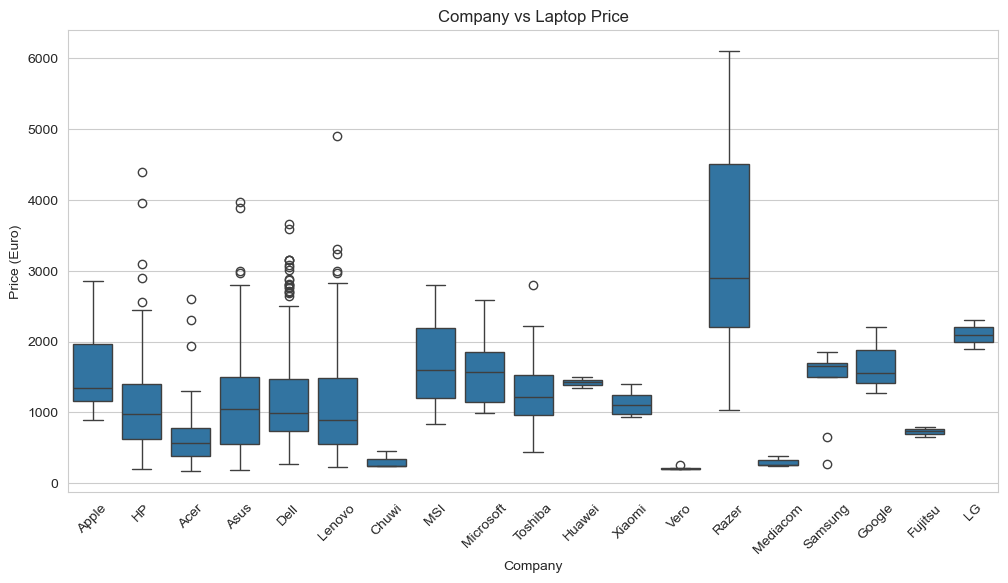

In [13]:
plt.figure(figsize=(12, 6))

sns.boxplot(x="Company", y="Price (Euro)", data=df)

plt.xticks(rotation=45)
plt.title("Company vs Laptop Price")
plt.xlabel("Company")
plt.ylabel("Price (Euro)")

plt.show()

## Company vs Price Observations

- Laptop prices vary considerably across different companies.
- Razer is concentrated in a relatively high-price segment.
- Acer, Chuwi, Mediacom and Vero generally have lower-priced laptops.
- Several companies contain high-price outliers.
- Company is an important feature, but it cannot alone explain laptop price.
- Other hardware specifications such as RAM, CPU, GPU and storage also influence price.

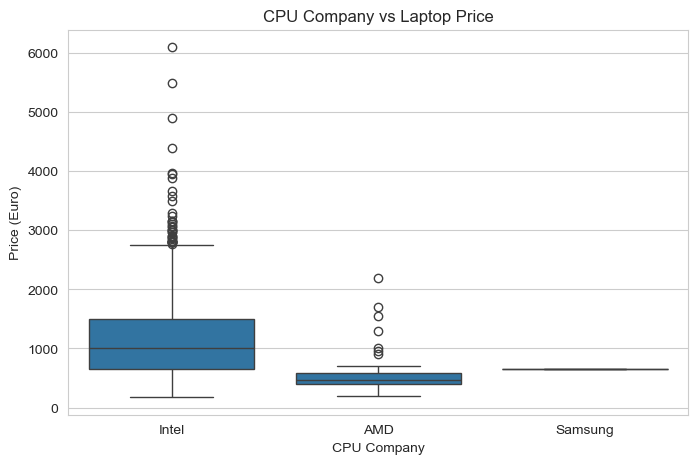

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="CPU_Company",
    y="Price (Euro)",
    data=df
)

plt.title("CPU Company vs Laptop Price")
plt.xlabel("CPU Company")
plt.ylabel("Price (Euro)")

plt.show()

## CPU Company vs Price Observations

- Intel laptops show the widest price variation in the dataset.
- Intel also contains several high-price outliers.
- AMD laptops are comparatively concentrated in a lower price range.
- Samsung has very few observations, so its distribution should be interpreted carefully.
- CPU company may influence laptop price, but other specifications also contribute significantly.

In [15]:
df[["RAM (GB)", "Price (Euro)"]].corr()

,RAM (GB),Price (Euro)
RAM (GB),1.000000,0.740287
Price (Euro),0.740287,1.000000


## RAM vs Price Correlation

The correlation between RAM and laptop price is approximately 0.74.

This indicates a strong positive relationship between RAM and price. 
Generally, laptops with higher RAM tend to have higher prices.

However, RAM alone cannot explain the complete variation in laptop prices, 
as other features such as CPU, GPU, storage and screen specifications also 
affect the price.

In [16]:
df[["CPU_Frequency (GHz)", "Price (Euro)"]].corr()

,CPU_Frequency (GHz),Price (Euro)
CPU_Frequency (GHz),1.000000,0.428847
Price (Euro),0.428847,1.000000


## CPU Frequency vs Price Correlation

The correlation between CPU frequency and laptop price is approximately 0.43.

This indicates a moderate positive relationship between CPU frequency and price.
Laptops with higher CPU frequencies tend to have higher prices, but the
relationship is not as strong as the relationship between RAM and price.

Therefore, CPU frequency can be considered a useful feature, but other
specifications also play an important role in predicting laptop prices.

In [17]:
df[["Weight (kg)", "Price (Euro)"]].corr()

,Weight (kg),Price (Euro)
Weight (kg),1.000000,0.211883
Price (Euro),0.211883,1.000000


## Numerical Features vs Price

| Feature | Correlation with Price |
|---------|------------------------|
| RAM | 0.740 |
| CPU Frequency | 0.429 |
| Weight | 0.212 |

### Observations

- RAM has the strongest positive correlation with laptop price.
- CPU frequency shows a moderate positive relationship with price.
- Weight has a weak positive relationship with price.
- Therefore, RAM appears to be an important numerical feature for price prediction.
- However, laptop price depends on multiple features, so these correlations alone are not sufficient for prediction.

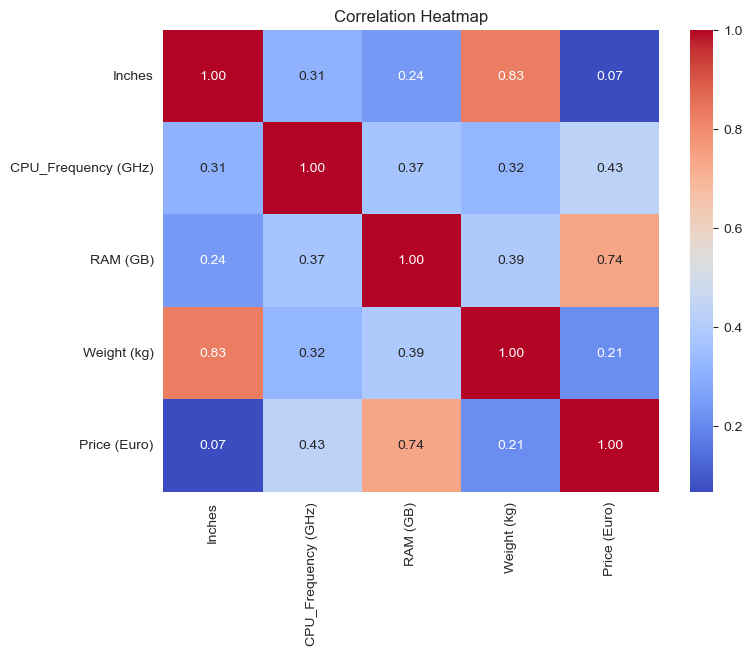

In [18]:
plt.figure(figsize=(8, 6))

corr = df[[
    "Inches",
    "CPU_Frequency (GHz)",
    "RAM (GB)",
    "Weight (kg)",
    "Price (Euro)"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Correlation Heatmap Observations

- RAM has the strongest positive correlation with laptop price (0.74).
- CPU frequency has a moderate positive correlation with price (0.43).
- Weight has a weak positive correlation with price (0.21).
- Screen size (Inches) has very little direct correlation with price (0.07).
- Inches and Weight have a strong positive correlation (0.83), indicating that larger-screen laptops tend to be heavier.
- RAM appears to be the most important numerical feature among the features analyzed for explaining price variation.

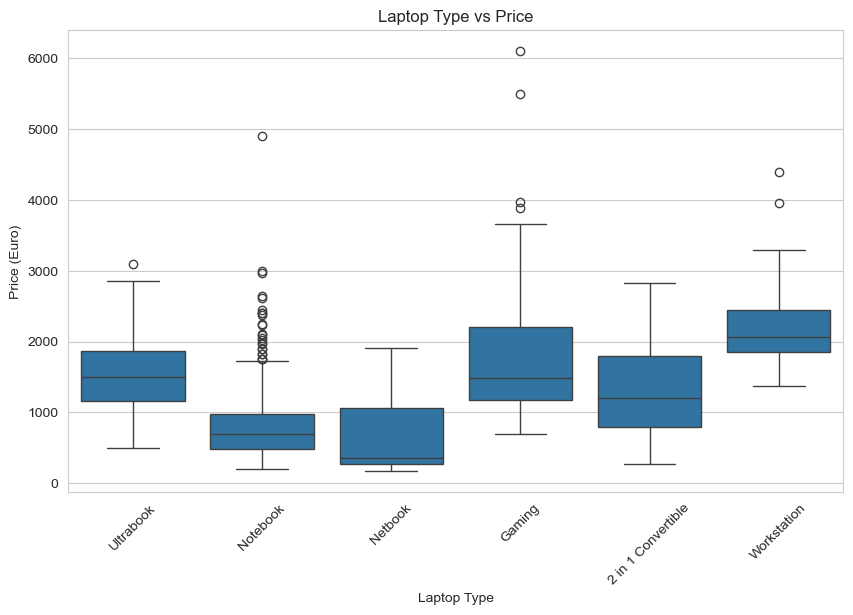

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="TypeName",
    y="Price (Euro)",
    data=df
)

plt.xticks(rotation=45)
plt.title("Laptop Type vs Price")
plt.xlabel("Laptop Type")
plt.ylabel("Price (Euro)")

plt.show()

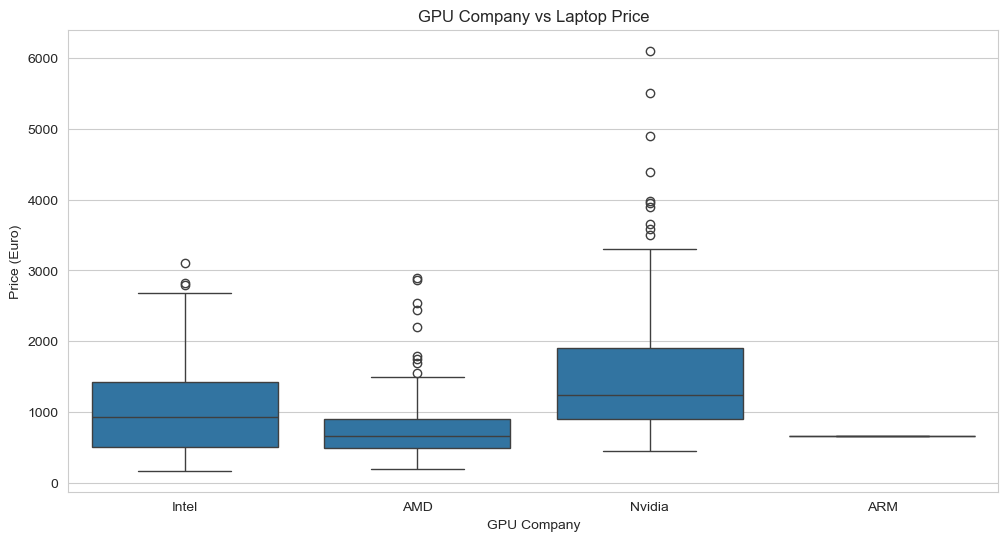

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(x="GPU_Company", y="Price (Euro)", data=df)

plt.title("GPU Company vs Laptop Price")
plt.xlabel("GPU Company")
plt.ylabel("Price (Euro)")

plt.show()

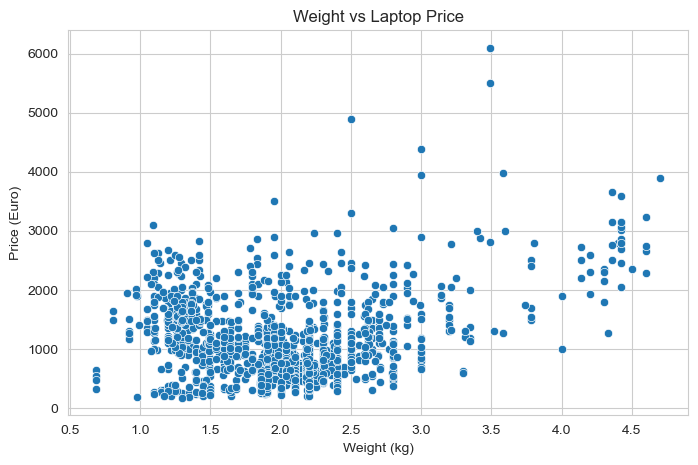

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Weight (kg)", y="Price (Euro)", data=df)

plt.title("Weight vs Laptop Price")
plt.xlabel("Weight (kg)")
plt.ylabel("Price (Euro)")

plt.show()

In [22]:
company_price = df.groupby("Company")["Price (Euro)"].mean().sort_values(ascending=False)

print(company_price)

Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1199.225120
Xiaomi       1133.462500
Asus         1123.829737
Lenovo       1093.862215
HP           1080.314664
Fujitsu       729.000000
Acer          633.464455
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price (Euro), dtype: float64


### Company-wise Price Observation

Razer has the highest average laptop price at approximately €3346,
while Vero has the lowest average price at approximately €217.

Premium brands such as Razer, LG, MSI, Google, Microsoft and Apple
generally have higher average laptop prices compared to budget-oriented
brands such as Vero, Mediacom, Chuwi and Acer.

This indicates that the company/brand can be an important categorical
feature for predicting laptop prices.

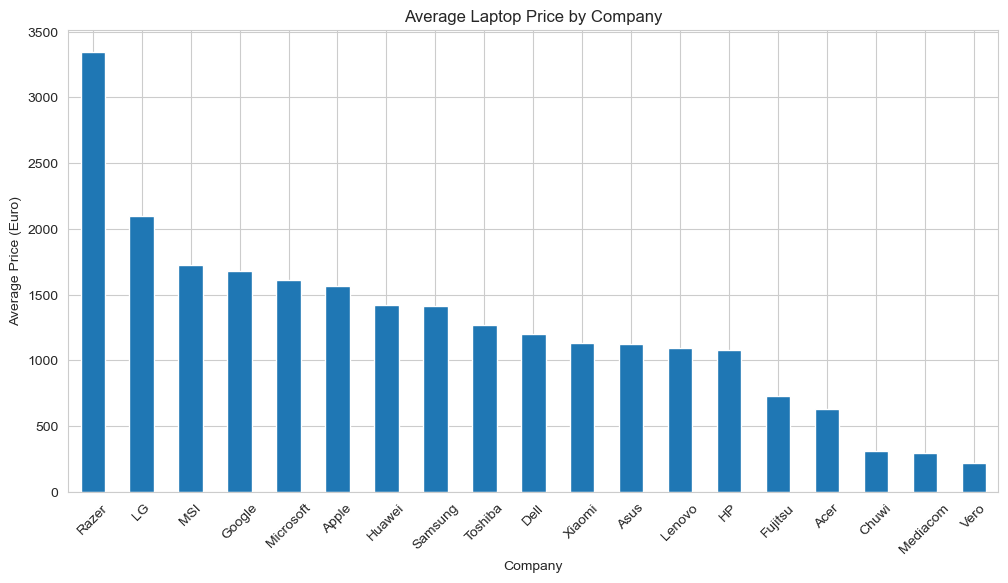

In [23]:
plt.figure(figsize=(12,6))

company_price.plot(kind="bar")

plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price (Euro)")

plt.xticks(rotation=45)
plt.show()

## EDA Insights

1. The dataset contains 1275 laptop records and 15 features.

2. There are no missing values in the dataset.

3. RAM has a strong positive relationship with laptop price, with a correlation of approximately 0.74.

4. CPU frequency has a moderate positive relationship with price, with a correlation of approximately 0.43.

5. Weight has a relatively weak relationship with laptop price, with a correlation of approximately 0.21.

6. Laptop prices vary significantly across different companies.

7. Higher RAM configurations generally correspond to higher laptop prices.

8. Premium laptop brands and configurations tend to have higher average prices.

9. The price distribution is right-skewed, meaning most laptops are in the lower-to-mid price range while a few premium laptops have much higher prices.

10. These observations will help in selecting useful features for the machine learning model.